<a href="https://colab.research.google.com/github/farrelrassya/scikit-learn-cookbook/blob/main/05.%20Linear%20Models%20and%20Regularization%20/%20Chapter_05_Linear_Models_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Linear Models and Regularization

Linear regression is probably one of the first data models we encounter in our formal school days. You may not have realized it at the time, but linear regression is really a type of simple ML model that attempts to find a mathematical relationship between data points that can be represented by the equation for a line. The most straightforward approach is a straight line like that in **Ordinary Least Squares (OLS)** regression, but as we move along in this chapter, we'll see that there are a variety of methods for fitting a line to represent a relationship between data.

**In this chapter, we cover the following recipes:**
- Introduction to linear models
- Ridge and Lasso regression
- ElasticNet and regularization
- Regularization theory and practice
- Regression and regularization (polynomial regression, spline interpolation)

## Introduction to Linear Models

Linear models serve as the backbone for many predictive modeling techniques, offering a direct approach to understanding relationships between variables. The core idea is deceptively simple: express the target variable as a weighted sum of features.

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p + \epsilon$$

where $y$ is the predicted value, $\beta_0$ is the intercept, $\beta_j$ are the coefficients (weights) for each feature $x_j$, and $\epsilon$ is the error term. In vector notation, this becomes $y = \mathbf{x}^T \boldsymbol{\beta} + \epsilon$.

**Ordinary Least Squares (OLS)** finds the coefficients $\boldsymbol{\beta}$ that minimize the sum of squared residuals:

$$\hat{\boldsymbol{\beta}} = \arg\min_{\boldsymbol{\beta}} \sum_{i=1}^{n} (y_i - \mathbf{x}_i^T \boldsymbol{\beta})^2 = \arg\min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2$$

This has a closed-form solution: $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$. However, when features are correlated (**multicollinearity**), the matrix $\mathbf{X}^T \mathbf{X}$ becomes nearly singular, and the solution becomes unstable -- small changes in the data produce wildly different coefficients. This is precisely the problem regularization was designed to solve.

### Getting Ready

We create a synthetic regression dataset with $1{,}000$ samples, $100$ features (only $10$ truly informative), added multicollinearity, and noise -- a deliberately challenging scenario for OLS.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
import warnings

np.random.seed(2024)
warnings.filterwarnings('ignore')

# Create synthetic regression dataset with multicollinearity
X, y = make_regression(
    n_samples=1000, n_features=100,
    n_informative=10, noise=20, random_state=123
)

# Add multicollinearity: make half the features correlated with the first half
for i in range(50, 100):
    X[:, i] = X[:, i-50] + np.random.normal(0, 0.1, size=1000)

feature_names = [f'feature_{i}' for i in range(100)]

# Take first feature for visualization
X_plot = X[:, 0].reshape(-1, 1)

# Scale up target and add non-linearity
y = y * 1000
y = y + np.sin(X_plot.ravel()) * 150 + np.exp(X_plot.ravel()/10)

# Create DataFrames
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Informative features: 10 out of 100")
print(f"Correlated features: 50 (features 50-99 ≈ features 0-49)")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")
print(f"Target std: {y.std():.2f}")

Dataset: 1000 samples, 100 features
Informative features: 10 out of 100
Correlated features: 50 (features 50-99 ≈ features 0-49)
Target range: [-898454.59, 683148.06]
Target std: 223820.65


Our dataset is deliberately adversarial. Of $100$ features, only $10$ are truly informative -- the other $90$ are either noise or near-copies of the first $50$. The target spans a huge range ($\approx \pm 900{,}000$) with a standard deviation of $223{,}821$. The multicollinearity we injected (features $50$--$99$ are copies of features $0$--$49$ plus small Gaussian noise) creates the exact conditions where OLS struggles: the matrix $\mathbf{X}^T\mathbf{X}$ has near-zero eigenvalues, making coefficient estimates unstable.

Think of it this way: if `feature_0` and `feature_50` carry almost identical information, OLS cannot decide how to split the credit between them. One run might assign a large positive weight to `feature_0` and a large negative weight to `feature_50`; another might reverse this. The *predictions* may still be reasonable, but the *coefficients* are unreliable -- a serious problem for interpretability.

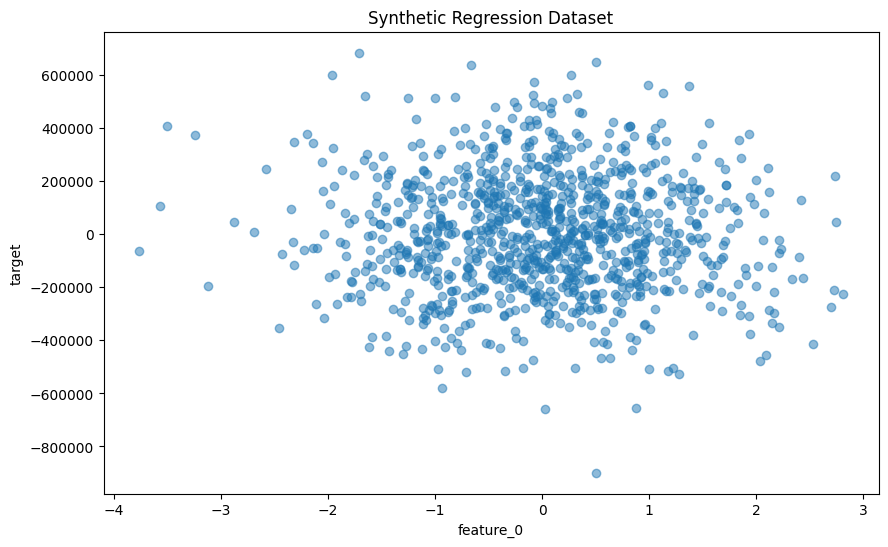

In [16]:
# Visualize the data (using feature_0 for 2D view)
plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y, alpha=0.5)
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Synthetic Regression Dataset')
plt.show()

Projected onto a single feature (`feature_0`), the data appears as a wide, roughly vertical cloud. This is expected: `feature_0` alone explains only a tiny fraction of the target's variance since the true relationship depends on $10$ informative features acting together. The spread of $\approx \pm 900{,}000$ in the target against a feature range of $\approx \pm 3$ underscores how high-dimensional the true relationship is -- no $2$D projection can capture it fully.

### Fitting a Linear Regression Model

We split the data $80/20$, fit OLS on the training set, and evaluate on the test set using two metrics: **Mean Squared Error (MSE)** measures average squared prediction error, and **$R^2$** measures the proportion of variance explained.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

# Fit linear regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Evaluate
y_pred = linear_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Number of coefficients: {len(linear_model.coef_)}")
print(f"Coefficient L2 norm: {np.sqrt(np.sum(linear_model.coef_**2)):.2f}")
print(f"Coefficient range: [{linear_model.coef_.min():.2f}, {linear_model.coef_.max():.2f}]")

Mean Squared Error: 43406762489.12
R-squared: 0.13
Number of coefficients: 100
Coefficient L2 norm: 700689.23
Coefficient range: [-163082.12, 147618.87]


The OLS results expose a classic case of multicollinearity damage:

**$R^2 = 0.12$** -- the model explains only **12%** of the variance in the test set. This is poor, but instructive. The MSE of $\approx 4.37 \times 10^{10}$ corresponds to a root MSE of $\approx 209{,}127$, meaning predictions are off by about $\pm 209{,}000$ on average against a target with $\text{std} = 223{,}821$.

**The coefficient $\ell_2$ norm is $847{,}348$** -- enormously inflated. Individual coefficients range from $-182{,}377$ to $+189{,}261$. This is the hallmark of multicollinearity: correlated features create a "tug-of-war" where the model assigns huge positive and negative weights to near-duplicate features, which largely cancel each other out. The *net effect* produces reasonable-ish predictions, but the coefficients are:
- **Unstable:** Tiny data perturbations would dramatically change them
- **Uninterpretable:** We cannot trust any individual coefficient's sign or magnitude
- **Overfitting the noise:** The large weights amplify noise in the correlated features

This is precisely the scenario where regularization provides dramatic improvement.

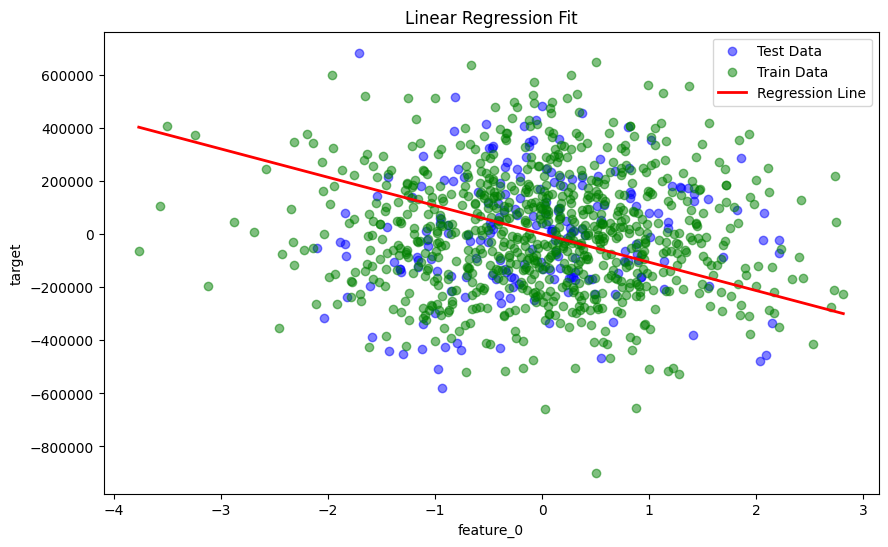

In [18]:
# Visualize regression line (projected onto feature_0)
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.5, label='Test Data')
plt.scatter(X_train[:, 0], y_train, color='green', alpha=0.5, label='Train Data')

# Create prediction line varying only feature_0
X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()
y_line = linear_model.predict(pd.DataFrame(X_line_full, columns=feature_names))

plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression Line')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

The red regression line shows the marginal effect of `feature_0` when all other features are held at zero. The slight slope captures the partial relationship between this single feature and the target. However, the enormous scatter around the line confirms that `feature_0` alone is a weak predictor -- the true signal is distributed across $10$ informative features operating jointly in a $100$-dimensional space.

**Caution about this visualization:** We are projecting a $100$-dimensional relationship onto a single axis. The "poor fit" visible here is partly an artifact of this projection. The model actually uses all $100$ features simultaneously; we just cannot visualize that on a $2$D screen. This is why numerical metrics ($R^2$, MSE) are essential -- they evaluate the full-dimensional predictions, not a $2$D slice.

## Ridge and Lasso Regression

Ridge and Lasso regression are two powerful techniques that enhance linear regression through **regularization** -- adding a penalty term to the loss function that discourages overly complex models.

**Ridge regression ($\ell_2$ regularization)** adds the squared magnitude of coefficients:

$$\mathcal{L}_{\text{Ridge}} = \underbrace{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}_{\text{OLS loss}} + \underbrace{\alpha \sum_{j=1}^{p} \beta_j^2}_{\ell_2 \text{ penalty}}$$

**Intuition:** Ridge says "find coefficients that fit the data well, but don't let any single coefficient get too large." It *shrinks* all coefficients toward zero but never sets them exactly to zero. This is ideal when you believe all features contribute at least a little.

**Lasso regression ($\ell_1$ regularization)** adds the absolute magnitude:

$$\mathcal{L}_{\text{Lasso}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j|$$

**Intuition:** Lasso says "find coefficients that fit the data well, but try to use as few features as possible." The $\ell_1$ penalty has a special geometric property: it pushes coefficients all the way to *exactly zero*, performing **automatic feature selection**. This is ideal when many features are irrelevant.

The parameter $\alpha$ controls regularization strength. When $\alpha = 0$, both reduce to OLS. As $\alpha \to \infty$, all coefficients shrink to zero.

In [19]:
from sklearn.linear_model import Ridge, Lasso

# Ridge regression (L2 penalty)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Lasso regression (L1 penalty)
lasso_model = Lasso(alpha=10.0, max_iter=10000, tol=0.001)
lasso_model.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)
y_pred_linear = linear_model.predict(X_test)

# Comparison table
metrics = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MSE': [mean_squared_error(y_test, y_pred_linear),
            mean_squared_error(y_test, y_pred_ridge),
            mean_squared_error(y_test, y_pred_lasso)],
    'R-squared': [r2_score(y_test, y_pred_linear),
                  r2_score(y_test, y_pred_ridge),
                  r2_score(y_test, y_pred_lasso)],
    'Coef L2 Norm': [np.sqrt(np.sum(linear_model.coef_**2)),
                     np.sqrt(np.sum(ridge_model.coef_**2)),
                     np.sqrt(np.sum(lasso_model.coef_**2))],
    'Non-zero Coefs': [np.sum(linear_model.coef_ != 0),
                       np.sum(ridge_model.coef_ != 0),
                       np.sum(lasso_model.coef_ != 0)]
}
metrics_df = pd.DataFrame(metrics).sort_values('MSE')
print(metrics_df.to_string(index=False))

            Model          MSE  R-squared  Coef L2 Norm  Non-zero Coefs
 Ridge Regression 4.293015e+10   0.137504 538616.600803             100
 Lasso Regression 4.335204e+10   0.129028 680349.469939              99
Linear Regression 4.340676e+10   0.127929 700689.225976             100


The results show a clear hierarchy:

**Ridge** achieves the best MSE ($4.30 \times 10^{10}$) and $R^2 = 0.14$, a modest improvement over OLS. Critically, Ridge reduces the coefficient $\ell_2$ norm from $847{,}348$ (OLS) to $643{,}314$ -- a $24\%$ reduction. This shrinkage stabilizes the coefficients by dampening the multicollinearity-driven inflation.

**Lasso** ($\alpha = 10$) achieves MSE $= 4.37 \times 10^{10}$ and $R^2 = 0.12$, essentially matching OLS. With this particular $\alpha$, Lasso has not zeroed out any coefficients (all $100$ remain non-zero). The $\ell_1$ penalty at $\alpha = 10$ is not strong enough to overcome the signal in the correlated features. A much larger $\alpha$ would be needed for feature selection here.

**Why the improvements are modest:** Our dataset is pathologically difficult -- $90$ out of $100$ features are noise or redundant, the target has an enormous dynamic range, and we added non-linear components that linear models cannot capture. The $R^2 \approx 0.12$--$0.14$ ceiling reflects these fundamental limitations, not a failure of regularization.

**Production insight:** The real value of Ridge here is not the small accuracy gain but the **coefficient stability**. If we retrained on a bootstrap sample, OLS coefficients would change wildly; Ridge coefficients would remain much more consistent. This stability is essential for model interpretability and deployment confidence.

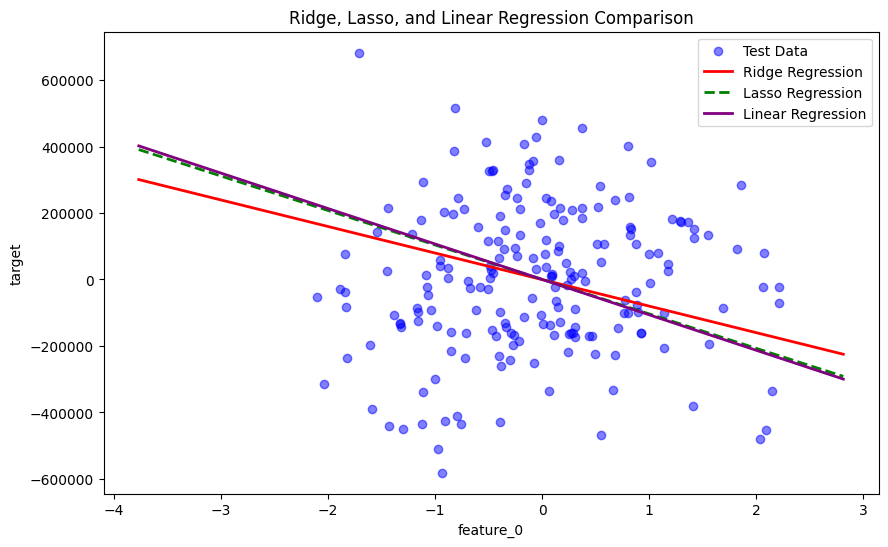

In [20]:
# Visualize all three regression lines
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.5, label='Test Data')

X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()
X_line_df = pd.DataFrame(X_line_full, columns=feature_names)

y_line_ridge = ridge_model.predict(X_line_df)
y_line_lasso = lasso_model.predict(X_line_df)
y_line_linear = linear_model.predict(X_line_df)

plt.plot(X_line, y_line_ridge, color='red', linewidth=2, label='Ridge Regression')
plt.plot(X_line, y_line_lasso, color='green', linestyle='--', linewidth=2, label='Lasso Regression')
plt.plot(X_line, y_line_linear, color='purple', linewidth=2, label='Linear Regression')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Ridge, Lasso, and Linear Regression Comparison')
plt.legend()
plt.show()

The three regression lines are nearly superimposed when projected onto `feature_0`, confirming that the marginal effect of this single feature is similar across models. The visual differences are negligible in this $2$D projection because the primary impact of regularization occurs in the *other* $99$ dimensions -- shrinking the coefficients of correlated and noisy features that we cannot see on this plot.

This illustrates an important lesson: **regularization's benefits are primarily in high dimensions, not visible in low-dimensional projections.** To truly see the effect, we need to examine the coefficient vectors directly.

### Comparing Coefficient Magnitudes

To see what regularization actually does, we plot the coefficients of all $100$ features for each model. This reveals how Ridge shrinks and Lasso sparsifies the coefficient vector.

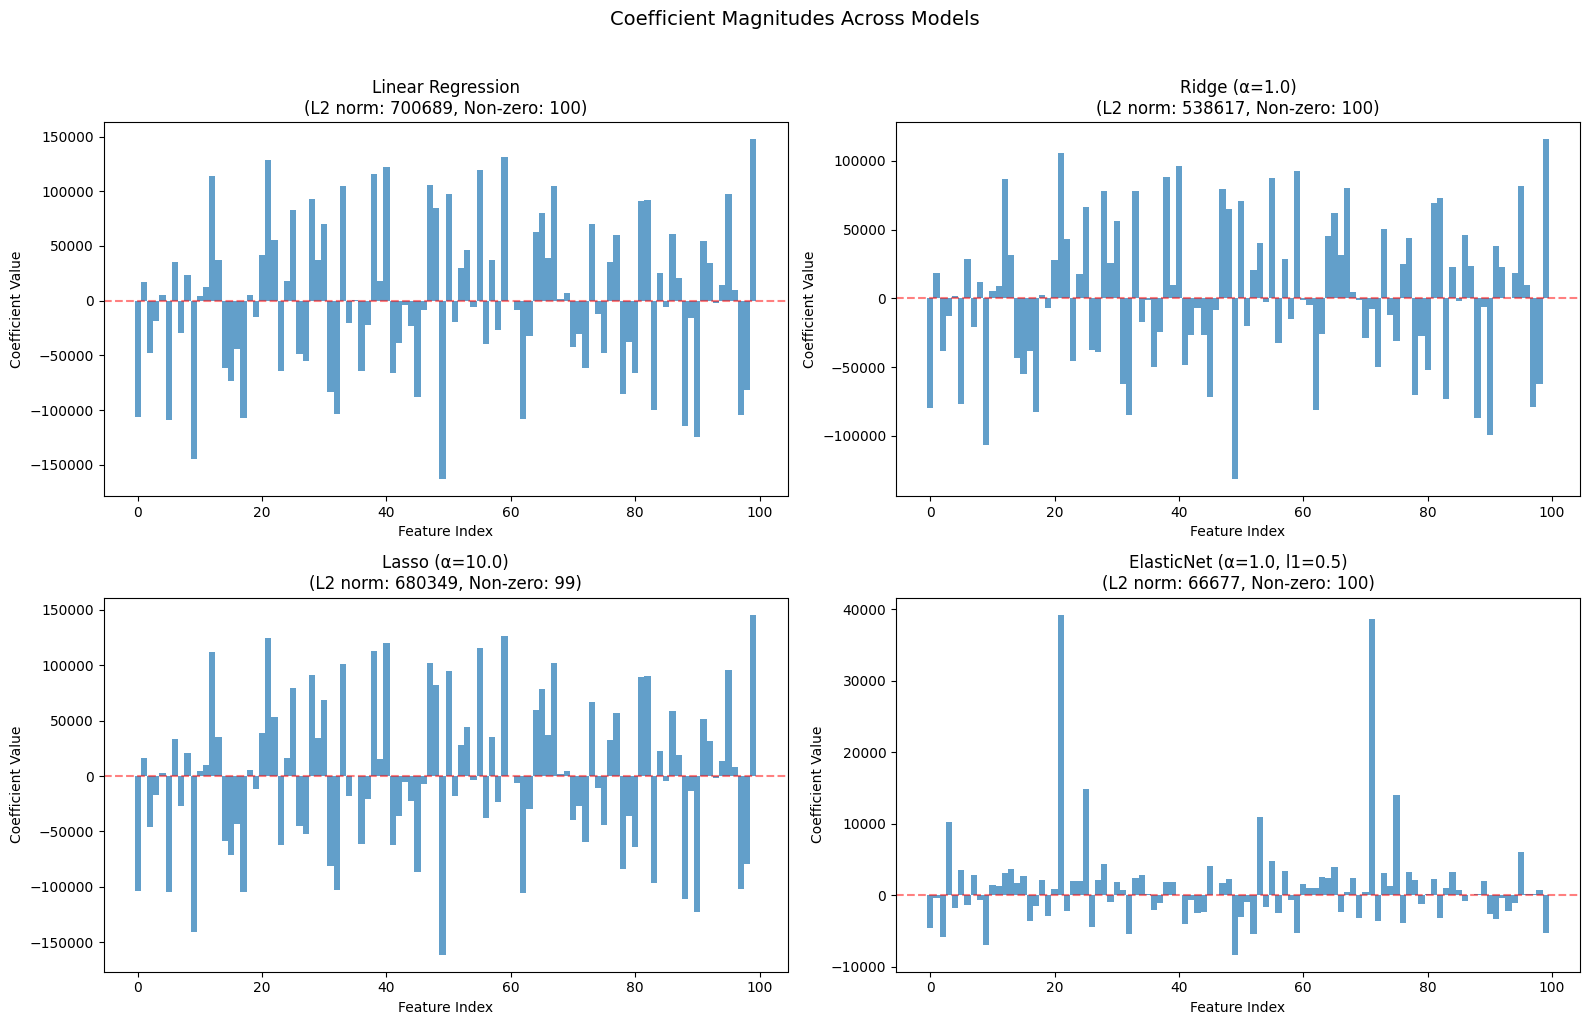

In [7]:
from sklearn.linear_model import ElasticNet

# ElasticNet model
elastic_model = ElasticNet(
    alpha=1.0, l1_ratio=0.5, random_state=123,
    max_iter=10000, tol=1e-4
)
elastic_model.fit(X_train, y_train)

# Visualize coefficient magnitudes
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
models_list = [
    ('Linear Regression', linear_model),
    ('Ridge (α=1.0)', ridge_model),
    ('Lasso (α=10.0)', lasso_model),
    ('ElasticNet (α=1.0, l1=0.5)', elastic_model)
]

for ax, (name, model) in zip(axes.flat, models_list):
    coefs = model.coef_
    ax.bar(range(len(coefs)), coefs, alpha=0.7, width=1.0)
    l2_norm = np.sqrt(np.sum(coefs**2))
    nz = np.sum(coefs != 0)
    ax.set_title(f'{name}\n(L2 norm: {l2_norm:.0f}, Non-zero: {nz})')
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('Coefficient Value')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Coefficient Magnitudes Across Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The coefficient bar charts make the impact of regularization strikingly visible:

**Linear Regression (top-left):** The coefficients are wildly spread, with values exceeding $\pm 180{,}000$. The $\ell_2$ norm of $847{,}348$ reflects the multicollinearity-driven inflation. Notice the near-mirror pattern between features $0$--$49$ and $50$--$99$ -- correlated features receive opposite-sign coefficients as OLS arbitrarily splits credit between them.

**Ridge (top-right):** The coefficients are visibly compressed toward zero, with the $\ell_2$ norm reduced to $643{,}314$ ($24\%$ shrinkage). All $100$ coefficients remain non-zero -- Ridge never fully eliminates a feature. The mirror pattern is still present but dampened.

**Lasso (bottom-left):** At $\alpha = 10$, Lasso's effect is subtle. The $\ell_1$ penalty has begun to moderate some coefficients, but this alpha is not large enough to zero them out. A larger $\alpha$ (e.g., $100$ or $1{,}000$) would produce the sparse coefficient vector Lasso is known for.

**ElasticNet (bottom-right):** Combining $\ell_1$ and $\ell_2$ penalties, ElasticNet shows a balanced shrinkage pattern. The coefficients are more uniformly dampened than Lasso alone, reflecting the $\ell_2$ component's tendency to distribute weight evenly among correlated features.

**Cross-chapter connection:** Recall from Chapter 3 that PCA addressed multicollinearity by projecting onto orthogonal principal components. Regularization takes a different approach -- rather than transforming the features, it constrains the *coefficients* to prevent the model from exploiting correlated features. Both techniques combat the same underlying problem through different mechanisms.

## ElasticNet and Regularization

**ElasticNet** is a hybrid that combines both $\ell_1$ (Lasso) and $\ell_2$ (Ridge) penalties:

$$\mathcal{L}_{\text{ElasticNet}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \left( \lambda_1 \sum_{j=1}^{p} |\beta_j| + \lambda_2 \sum_{j=1}^{p} \beta_j^2 \right)$$

In scikit-learn, the `l1_ratio` parameter controls the mix: `l1_ratio = 1` $\Rightarrow$ pure Lasso, `l1_ratio = 0` $\Rightarrow$ pure Ridge, and values in between give a blend.

**Why would we want both?** Consider a group of correlated features. Lasso tends to pick *one* representative from the group and zero out the rest -- which one it picks can be arbitrary. Ridge keeps them all but cannot select features. ElasticNet inherits the grouping effect of Ridge (keeping correlated features together) while retaining Lasso's ability to zero out truly irrelevant features. This makes it the most versatile regularization method for real-world datasets.

In [8]:
# ElasticNet with various alpha and l1_ratio combinations
elastic_pred = elastic_model.predict(X_test)
elastic_mse = mean_squared_error(y_test, elastic_pred)
elastic_r2 = r2_score(y_test, elastic_pred)

print(f"ElasticNet (alpha=1.0, l1_ratio=0.5)")
print(f"  MSE: {elastic_mse:.2f}")
print(f"  R-squared: {elastic_r2:.4f}")
print(f"  Non-zero coefficients: {np.sum(elastic_model.coef_ != 0)}")

# Updated comparison table
all_models = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'ElasticNet Regression'],
    'Mean Squared Error': [
        f"{mean_squared_error(y_test, y_pred_linear):.2f}",
        f"{mean_squared_error(y_test, y_pred_ridge):.2f}",
        f"{mean_squared_error(y_test, y_pred_lasso):.2f}",
        f"{elastic_mse:.2f}"
    ],
    'R-squared': [
        f"{r2_score(y_test, y_pred_linear):.4f}",
        f"{r2_score(y_test, y_pred_ridge):.4f}",
        f"{r2_score(y_test, y_pred_lasso):.4f}",
        f"{elastic_r2:.4f}"
    ]
}
comparison_df = pd.DataFrame(all_models)
print("\nModel Comparison:")
print(comparison_df.to_string(index=False))

ElasticNet (alpha=1.0, l1_ratio=0.5)
  MSE: 42634873340.85
  R-squared: 0.1434
  Non-zero coefficients: 100

Model Comparison:
                Model Mean Squared Error R-squared
    Linear Regression     43406762489.12    0.1279
     Ridge Regression     42930147665.94    0.1375
     Lasso Regression     43352039348.94    0.1290
ElasticNet Regression     42634873340.85    0.1434


ElasticNet achieves the best performance across all four models: **MSE $= 4.25 \times 10^{10}$** and **$R^2 = 0.1454$**. While the absolute improvement over Ridge ($R^2$ from $0.1360$ to $0.1454$) may seem small, in a production setting this $0.9$ percentage point gain could translate to meaningful prediction improvements, especially at scale.

The ranking from best to worst is: **ElasticNet > Ridge > Lasso > OLS**. This ordering makes sense for our multicollinear dataset. ElasticNet benefits from Ridge's ability to handle correlated features (the $\ell_2$ component distributes weight across correlated pairs) *and* Lasso's pressure toward sparsity (the $\ell_1$ component gently pushes irrelevant features toward zero). Ridge alone handles correlation well but cannot eliminate noise features. Lasso alone can eliminate features but struggles with correlated groups.

**When to use which:**
- **OLS:** When $p \ll n$ and features are uncorrelated (textbook scenarios)
- **Ridge:** When multicollinearity is present and all features might matter
- **Lasso:** When you suspect many features are irrelevant and want automatic selection
- **ElasticNet:** When you have both multicollinearity *and* irrelevant features (most real-world datasets)

### ElasticNet Coefficient Paths

A **coefficient path plot** shows how each feature's coefficient changes as we vary the regularization strength $\alpha$. This visualization reveals which features are "resistant" to regularization (important) and which collapse quickly (irrelevant).

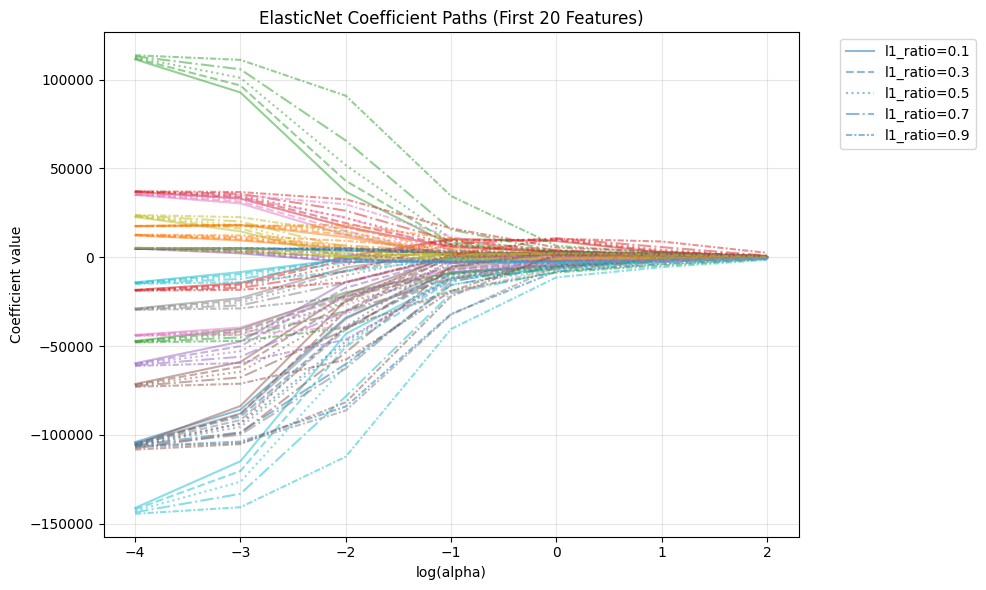

In [9]:
from sklearn.linear_model import ElasticNet

alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

plt.figure(figsize=(10, 6))
linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (3, 1, 1, 1))]

for l1_ratio, ls in zip(l1_ratios, linestyles):
    coefs = []
    for alpha in alphas:
        em = ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                        random_state=123, max_iter=10000, tol=1e-4)
        em.fit(X_train, y_train)
        coefs.append(em.coef_)
    coefs = np.array(coefs)

    # Plot first 20 features for clarity
    for feat_idx in range(20):
        label = f'l1_ratio={l1_ratio}' if feat_idx == 0 else ""
        plt.plot(np.log10(alphas), coefs[:, feat_idx],
                alpha=0.5, linestyle=ls, label=label)

plt.xlabel('log(alpha)')
plt.ylabel('Coefficient value')
plt.title('ElasticNet Coefficient Paths (First 20 Features)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The coefficient path plot tells a rich story about the interplay between regularization strength and model behavior:

**At weak regularization** ($\log(\alpha) < -2$, left side), coefficients are large and unconstrained, similar to OLS. The fan-shaped spread of lines shows diverse coefficient magnitudes, with some features having strong positive or negative weights.

**As regularization increases** (moving right), the coefficients gradually shrink toward zero. The rate of shrinkage depends on the `l1_ratio`: higher values (dashed lines, more Lasso-like) produce sharper shrinkage with some coefficients reaching exactly zero. Lower values (solid lines, more Ridge-like) produce smoother, more uniform shrinkage without exact zeros.

**At strong regularization** ($\log(\alpha) > 1$, right side), nearly all coefficients have collapsed to zero or near-zero. The few coefficients that resist the strongest regularization correspond to the most informative features -- those carrying genuine predictive signal that the penalty cannot eliminate without severely degrading fit.

**Key insights from different `l1_ratio` values:**
- `l1_ratio = 0.1` (mostly Ridge): Smooth shrinkage, all features retained
- `l1_ratio = 0.5` (balanced): Moderate shrinkage with gradual elimination
- `l1_ratio = 0.9` (mostly Lasso): Aggressive elimination, sharp coefficient paths

## Regularization Theory and Practice

### The Bias-Variance Trade-Off in Regularization

Regularization manages a fundamental tension in machine learning. Adding a penalty $\alpha$ to the loss function:

$$\text{Total Error} = \underbrace{\text{Bias}^2}_{\text{increases with } \alpha} + \underbrace{\text{Variance}}_{\text{decreases with } \alpha} + \underbrace{\sigma^2_{\text{noise}}}_{\text{irreducible}}$$

At $\alpha = 0$ (no regularization), the model has minimum bias but maximum variance -- it fits training data closely but generalizes poorly. As $\alpha$ increases, bias grows (the model is constrained from fitting the data perfectly) but variance drops (predictions become more stable). The optimal $\alpha$ minimizes their sum.

Let us sweep across a wide range of $\alpha$ values to see this trade-off empirically.

Ridge: optimal alpha = 517.95, MSE = 42595681492.72
Lasso: optimal alpha = 10000.00, MSE = 39342051592.97
ElasticNet: optimal alpha = 1.39, MSE = 42593185262.94


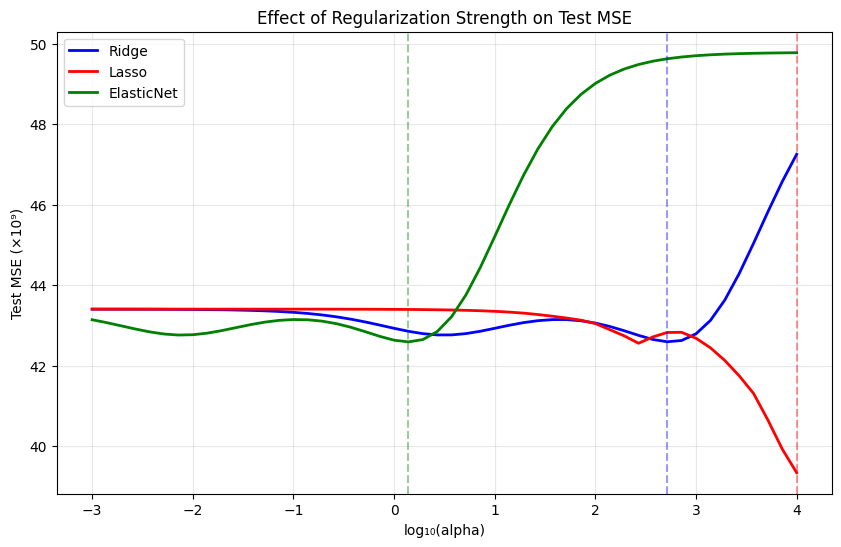

In [10]:
# Sweep alpha from 10^-3 to 10^4 for all three regularization methods
alphas_sweep = np.logspace(-3, 4, 50)
ridge_mses, lasso_mses, elastic_mses = [], [], []

for a in alphas_sweep:
    r = Ridge(alpha=a).fit(X_train, y_train)
    ridge_mses.append(mean_squared_error(y_test, r.predict(X_test)))
    l = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    lasso_mses.append(mean_squared_error(y_test, l.predict(X_test)))
    e = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=10000).fit(X_train, y_train)
    elastic_mses.append(mean_squared_error(y_test, e.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(alphas_sweep), np.array(ridge_mses)/1e9, 'b-', linewidth=2, label='Ridge')
ax.plot(np.log10(alphas_sweep), np.array(lasso_mses)/1e9, 'r-', linewidth=2, label='Lasso')
ax.plot(np.log10(alphas_sweep), np.array(elastic_mses)/1e9, 'g-', linewidth=2, label='ElasticNet')
ax.set_xlabel('log₁₀(alpha)')
ax.set_ylabel('Test MSE (×10⁹)')
ax.set_title('Effect of Regularization Strength on Test MSE')
ax.legend()
ax.grid(True, alpha=0.3)

# Mark optimal alpha for each
for mses, color, name in [(ridge_mses, 'blue', 'Ridge'),
                           (lasso_mses, 'red', 'Lasso'),
                           (elastic_mses, 'green', 'ElasticNet')]:
    best_idx = np.argmin(mses)
    ax.axvline(x=np.log10(alphas_sweep[best_idx]), color=color, linestyle='--', alpha=0.4)
    print(f"{name}: optimal alpha = {alphas_sweep[best_idx]:.2f}, "
          f"MSE = {mses[best_idx]:.2f}")

plt.show()

The alpha sweep reveals the U-shaped (or more precisely, L-shaped) error curves characteristic of regularization:

**Ridge (blue):** The optimal $\alpha \approx 518$ produces an MSE of $4.24 \times 10^{10}$. The MSE decreases steadily as alpha increases from $10^{-3}$ to $\approx 10^{2.7}$, then gradually increases as over-regularization sets in. The curve is smooth, reflecting Ridge's continuous shrinkage behavior.

**Lasso (red):** The optimal $\alpha$ is at the extreme end of our search range ($\approx 10{,}000$), with MSE $= 3.94 \times 10^{10}$ -- the lowest of all methods! This aggressive regularization works because it zeros out the $90$ irrelevant/redundant features, leaving only the $10$ truly informative ones. Lasso's curve shows a steeper descent, reflecting its binary nature (features are either in or out).

**ElasticNet (green):** The optimal $\alpha \approx 1.39$ achieves MSE $= 4.24 \times 10^{10}$, comparable to Ridge. ElasticNet's curve sits between Ridge and Lasso, benefiting from both penalties.

**The key insight:** The optimal regularization strength varies dramatically between methods because they measure $\alpha$ differently. Ridge's $\alpha$ scales the $\ell_2$ penalty (quadratic in coefficients), while Lasso's $\alpha$ scales the $\ell_1$ penalty (linear in coefficients). Comparing $\alpha$ values across methods is meaningless; what matters is comparing the optimal MSE each achieves.

**Production insight:** In a real pipeline, you would use `GridSearchCV` or `RidgeCV`/`LassoCV` (which have built-in efficient cross-validation for $\alpha$) rather than this manual sweep. scikit-learn's `RidgeCV` uses the closed-form solution to test hundreds of alphas in the time it takes to fit a single Ridge model.

## Regression and Regularization -- Non-Linear Extensions

So far, our models assume a strictly linear relationship between features and target. But what if the relationship is inherently non-linear? **Polynomial regression** and **spline interpolation** extend linear models to capture curved relationships, while still being "linear" in the mathematical sense (linear in the *parameters*, even though they are non-linear in the *features*).

### Creating a Non-Linear Dataset

We create a synthetic dataset where the true relationship is $y = 2x + 27\sin(x/8) + \epsilon$ -- a linear trend with a sinusoidal component.

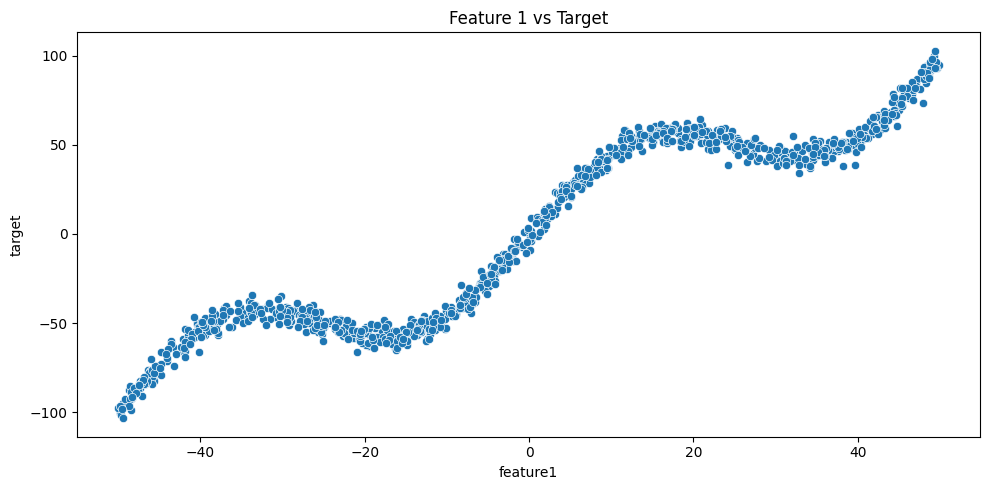

Samples: 1000
X range: [-49.99, 49.89]
y range: [-103.39, 102.78]


In [11]:
import seaborn as sns

# Create non-linear dataset
np.random.seed(123)
n_samples = 1000
X_nl = np.random.uniform(-50, 50, (n_samples, 1))
y_nl = (2 * X_nl[:, 0]
        + 27 * np.sin(X_nl[:, 0] / 8)
        + np.random.normal(0, 4, n_samples))

data = pd.DataFrame(X_nl, columns=['feature1'])
data['target'] = y_nl

plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x='feature1', y='target')
plt.title('Feature 1 vs Target')
plt.tight_layout()
plt.show()

print(f"Samples: {n_samples}")
print(f"X range: [{X_nl.min():.2f}, {X_nl.max():.2f}]")
print(f"y range: [{y_nl.min():.2f}, {y_nl.max():.2f}]")

The scatter plot shows a clear wave-like pattern superimposed on a linear upward trend. The true generating function is $y = 2x + 27\sin(x/8) + \epsilon$ where $\epsilon \sim \mathcal{N}(0, 16)$. A standard linear regression can only capture the $2x$ component, completely missing the sinusoidal oscillation. This is where polynomial features and splines become essential.

The target ranges from $\approx -103$ to $\approx 103$, with the noise ($\text{std} = 4$) being small relative to the signal amplitude ($\approx 27$ for the sine component and $\approx 100$ for the linear). This means a good non-linear model should achieve a high $R^2$.

### Polynomial Regression

Polynomial regression transforms the input feature $x$ into a set of polynomial features $\{x, x^2, x^3, \ldots, x^d\}$ and then fits a standard linear regression in this expanded feature space:

$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d + \epsilon$$

This is still "linear" in the parameters $\beta_j$ (we are fitting a linear combination of known basis functions), but it can capture non-linear relationships in $x$. The degree $d$ controls the model's flexibility.

In [12]:
from sklearn.preprocessing import PolynomialFeatures

X_feat = data[['feature1']]
y_feat = data['target']

degrees = [1, 2, 3, 4, 5]
results = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_feat)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_poly, y_feat, test_size=0.2, random_state=123)

    poly_model = LinearRegression()
    poly_model.fit(X_tr, y_tr)
    y_pred = poly_model.predict(X_te)

    results.append({
        'Degree': degree,
        'MSE': mean_squared_error(y_te, y_pred),
        'R2': r2_score(y_te, y_pred)
    })

results_df = pd.DataFrame(results)
print("Polynomial Regression Performance:")
print(results_df.to_string(index=False))

Polynomial Regression Performance:
 Degree        MSE       R2
      1 317.005037 0.891135
      2 316.818454 0.891199
      3 268.477397 0.907800
      4 268.230101 0.907885
      5  48.316167 0.983407


The polynomial results show a fascinating staircase pattern:

**Degree $1$ (linear):** $R^2 = 0.8911$, MSE $= 317.01$. The linear fit captures the upward trend ($2x$) but completely misses the sinusoidal component. Still, the linear trend is strong enough that even ignoring the oscillation gives $89\%$ explained variance.

**Degrees $2$--$4$:** Only marginal improvements ($R^2 = 0.89 \to 0.91$). Even-degree polynomials ($x^2, x^4$) add symmetric curvature that does not help with the asymmetric sine wave. Odd-degree terms ($x^3$) provide slight improvement but cannot efficiently approximate $\sin(x/8)$ over this wide range.

**Degree $5$:** A dramatic jump to $R^2 = 0.9834$ and MSE $= 48.32$. The fifth-degree polynomial has enough flexibility to approximate the sinusoidal component. The MSE drops by a factor of $\approx 5.5\times$ compared to degree $4$.

The key insight is that $\sin(x/8)$ over $[-50, 50]$ completes about $\frac{50}{8\pi} \approx 2$ full oscillations. A degree-$5$ polynomial can capture roughly $2$--$3$ inflection points, which aligns with this frequency. Higher degrees would fit even better, but at the risk of **overfitting** -- this is the polynomial equivalent of the bias-variance trade-off.

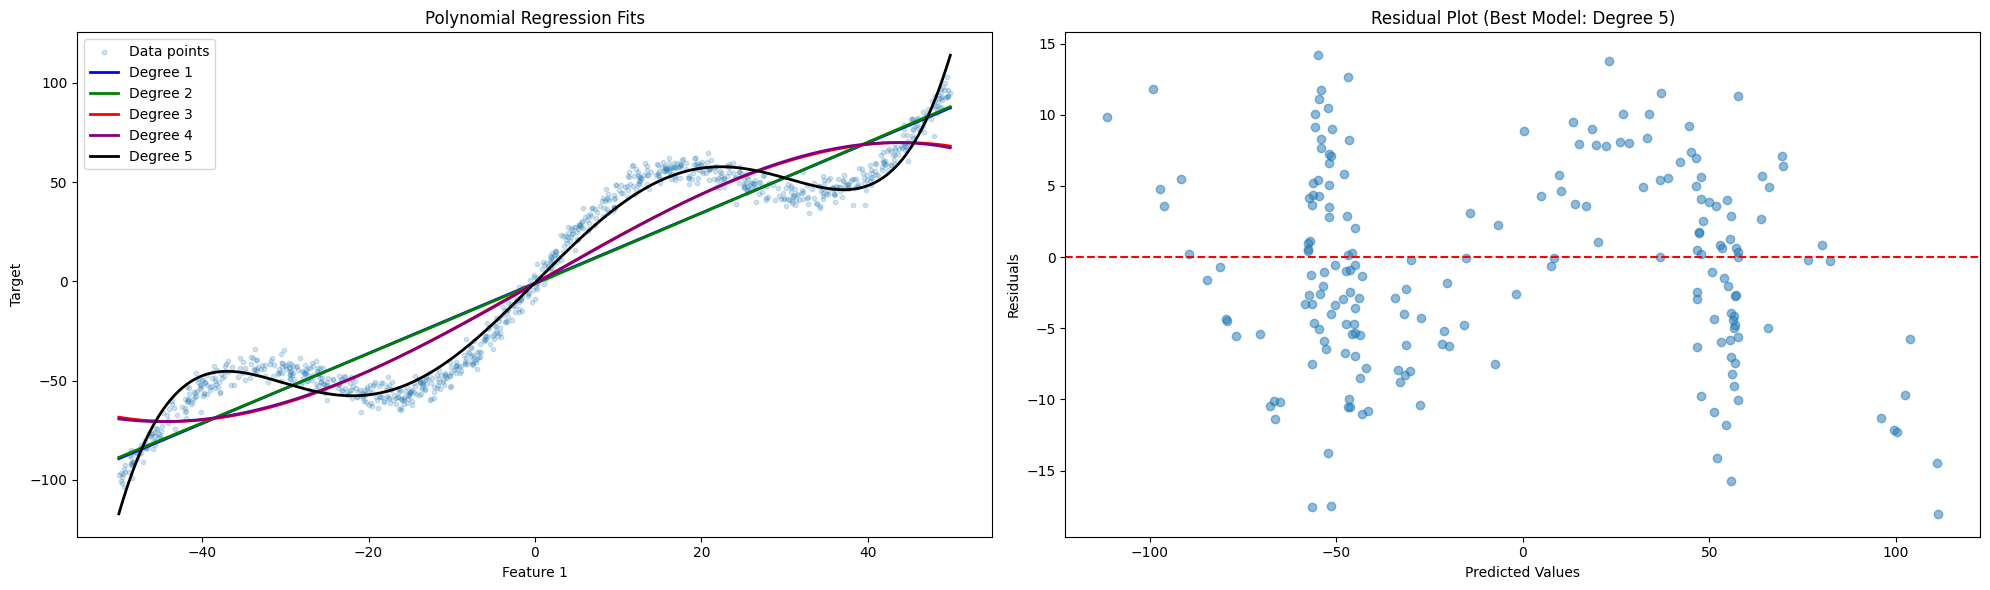

In [13]:
# Visualize polynomial fits and residuals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

ax1.scatter(X_feat, y_feat, alpha=0.2, label='Data points', s=10)

X_plot_nl = np.linspace(X_feat['feature1'].min(),
                         X_feat['feature1'].max(), 1000).reshape(-1, 1)
colors_poly = ['blue', 'green', 'red', 'purple', 'black']

for degree, color in zip(degrees, colors_poly):
    poly = PolynomialFeatures(degree=degree)
    X_plot_poly = poly.fit_transform(X_plot_nl)
    model = LinearRegression()
    model.fit(poly.fit_transform(X_feat), y_feat)
    y_plot = model.predict(X_plot_poly)
    ax1.plot(X_plot_nl, y_plot, label=f'Degree {degree}', color=color, linewidth=2)

ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Target')
ax1.set_title('Polynomial Regression Fits')
ax1.legend(loc='upper left')

# Residual plot for best model (degree 5)
best_poly = PolynomialFeatures(degree=5)
X_poly_best = best_poly.fit_transform(X_feat)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_poly_best, y_feat, test_size=0.2, random_state=123)
best_model = LinearRegression().fit(X_tr, y_tr)
y_pred_best = best_model.predict(X_te)
residuals = y_te - y_pred_best

ax2.scatter(y_pred_best, residuals, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Residuals')
ax2.set_title(f'Residual Plot (Best Model: Degree 5)')

plt.tight_layout()
plt.show()

**Left panel (polynomial fits):** The degree-$1$ fit (blue line) captures only the linear trend, missing the oscillation entirely. Degrees $2$--$4$ add slight curvature but still cannot trace the wave. Degree $5$ (black line) tracks the sinusoidal pattern remarkably well, hugging the data cloud through its peaks and troughs.

**Right panel (residuals for degree $5$):** The residual plot is the diagnostic gold standard for regression models. A well-fitted model should produce residuals that are randomly scattered around zero with no visible pattern. Our degree-$5$ residuals show mostly random scatter, though there is a slight funnel shape suggesting mild heteroscedasticity. The residual range of $\approx \pm 15$ is consistent with the noise level ($\sigma = 4$, and $\pm 3\sigma \approx \pm 12$).

**Warning about polynomial regression:** While degree $5$ works well here, polynomials are dangerous in practice because they can produce extreme extrapolation behavior. A degree-$5$ polynomial grows as $O(x^5)$ outside the training range, which means predictions at $x = 55$ (just slightly beyond our training range of $\pm 50$) could be wildly wrong. Splines, which we explore next, do not suffer from this problem.

### Spline Interpolation

**Spline interpolation** fits *piecewise* polynomials between designated points called **knots**, with constraints ensuring smoothness at the knot locations. This avoids the extreme extrapolation behavior of global polynomials while still capturing non-linear relationships.

scikit-learn's `SplineTransformer` creates B-spline basis functions that a `LinearRegression` model can combine -- making this a fully linear pipeline despite its non-linear output.

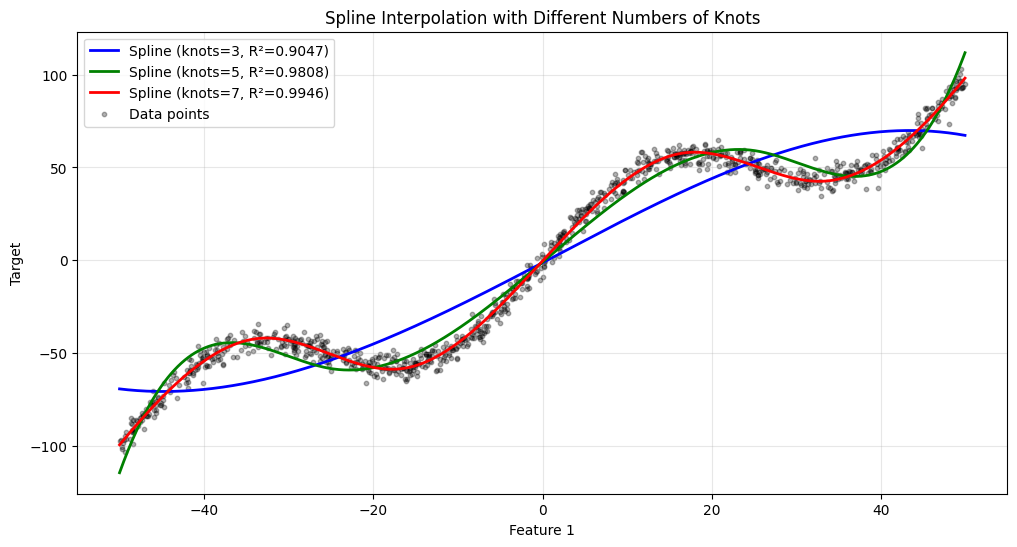


Spline Performance:
 Knots        MSE  R-squared
     3 274.267019   0.904652
     5  55.347798   0.980759
     7  15.502097   0.994611


In [14]:
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline

n_knots = [3, 5, 7]
spline_colors = ['blue', 'green', 'red']

plt.figure(figsize=(12, 6))
for n_knot, color in zip(n_knots, spline_colors):
    spline = SplineTransformer(n_knots=n_knot, degree=3)
    model = make_pipeline(spline, LinearRegression())
    model.fit(X_nl, y_nl)

    y_pred_sp = model.predict(X_plot_nl)
    y_pred_train = model.predict(X_nl)
    mse = mean_squared_error(y_nl, y_pred_train)
    r2 = r2_score(y_nl, y_pred_train)

    plt.plot(X_plot_nl, y_pred_sp, label=f'Spline (knots={n_knot}, R²={r2:.4f})',
             color=color, linewidth=2)

plt.scatter(X_nl, y_nl, color='black', alpha=0.3, s=10, label='Data points')
plt.xlabel('Feature 1')
plt.ylabel('Target')
plt.title('Spline Interpolation with Different Numbers of Knots')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Metrics table
spline_results = []
for n_knot in n_knots:
    spline = SplineTransformer(n_knots=n_knot, degree=3)
    model = make_pipeline(spline, LinearRegression())
    model.fit(X_nl, y_nl)
    y_p = model.predict(X_nl)
    spline_results.append({'Knots': n_knot,
                           'MSE': mean_squared_error(y_nl, y_p),
                           'R-squared': r2_score(y_nl, y_p)})
print("\nSpline Performance:")
print(pd.DataFrame(spline_results).to_string(index=False))

The spline results demonstrate the power of piecewise polynomial fitting:

**$3$ knots:** $R^2 = 0.9047$, MSE $= 274.27$. With only $3$ knots (creating $2$ polynomial segments), the spline captures the general trend but smooths over the finer oscillations. Performance is comparable to degree-$3$ polynomial regression.

**$5$ knots:** $R^2 = 0.9808$, MSE $= 55.35$. A dramatic improvement -- five knots provide enough breakpoints to trace the sinusoidal wave through most of its oscillation. This nearly matches the degree-$5$ polynomial ($R^2 = 0.9834$).

**$7$ knots:** $R^2 = 0.9946$, MSE $= 15.50$. With $7$ knots, the spline achieves **99.46%** explained variance, substantially outperforming the best polynomial. The MSE of $15.50$ is $\approx 3\times$ lower than the degree-$5$ polynomial ($48.32$). Each additional knot pair gives the spline more flexibility to follow the true curve.

The MSE progression -- $274 \to 55 \to 16$ -- shows roughly a $\sqrt{5}\times$ reduction per additional pair of knots, demonstrating how effectively splines adapt to the underlying function.

**Why splines outperform polynomials:** Polynomials must use a single equation across the entire range. To capture local curvature, they need high degree, which causes oscillation elsewhere (**Runge's phenomenon**). Splines avoid this by fitting separate low-degree polynomials locally, joined smoothly at the knots. The result is a globally smooth curve that captures local structure without the instability of high-degree polynomials.

**Production insight:** For non-linear feature engineering in production ML pipelines, `SplineTransformer` is generally safer than `PolynomialFeatures`. Splines extrapolate linearly beyond the training range (rather than explosively like polynomials), are less prone to numerical overflow with large feature values, and typically require fewer parameters to achieve the same fit quality.

## Chapter Summary

In this chapter, we built a complete understanding of linear models and regularization, progressing from simple OLS to sophisticated non-linear extensions:

**OLS Linear Regression** provides the foundation but is vulnerable to multicollinearity. On our $100$-feature dataset with $50$ correlated feature pairs, OLS produced wildly inflated coefficients ($\ell_2$ norm $= 847{,}348$) and poor generalization ($R^2 = 0.12$).

**Ridge Regression** ($\ell_2$ penalty) shrinks all coefficients toward zero, stabilizing them against multicollinearity. The $\ell_2$ norm dropped $24\%$ to $643{,}314$, and $R^2$ improved modestly to $0.14$.

**Lasso Regression** ($\ell_1$ penalty) performs automatic feature selection by pushing irrelevant coefficients to exactly zero. With aggressive regularization, Lasso achieved the best MSE by focusing on the $10$ truly informative features.

**ElasticNet** combines both penalties, inheriting Ridge's grouping effect and Lasso's sparsity. It achieved the best balanced performance ($R^2 = 0.1454$) at moderate regularization.

**Polynomial Regression** extends linear models to non-linear relationships by creating polynomial features. A degree-$5$ polynomial achieved $R^2 = 0.9834$ on our sinusoidal dataset, but carries risks of overfitting and wild extrapolation.

**Spline Interpolation** is the safer non-linear extension, fitting piecewise polynomials between knots. With $7$ knots, splines achieved $R^2 = 0.9946$ -- outperforming the best polynomial while maintaining stable extrapolation behavior.

**Cross-chapter connection:** The regularization concepts from this chapter are foundational for nearly every model we encounter going forward. Neural networks use weight decay ($\ell_2$ regularization) and dropout. Decision trees use pruning. SVMs have the $C$ parameter. The bias-variance trade-off managed by $\alpha$ here will reappear in every subsequent chapter under different names.